In [1]:
import kagglehub

kagglehub.dataset_download("yusufmurtaza01/grape-leaf-diseases", output_dir='data')

'data'

In [2]:
import numpy as np
import pandas as pd 
from tqdm import tqdm
import os 
from PIL import Image

image_path = 'data/grape/images/train/'
label_path = 'data/grape/labels/train/'

image_val_path = 'data/grape/images/val/'
label_val_path = 'data/grape/labels/val/'

raw_train_image = []
raw_val_image = []
records = []
for image_name in tqdm(os.listdir(image_path)):
    with Image.open(image_path + image_name) as img:
        raw_train_image.append(img.copy())     
    label_name = image_name.replace('.jpg', ".txt")
    with open(label_path + label_name, "r") as f:
        label = f.read()
    records.append({
        "file_name": image_name,
        "class": label[0],
    })

df_train = pd.DataFrame(records, columns=['file_name', 'class']) 

records = []
for image_name in tqdm(os.listdir(image_val_path)):
    with Image.open(image_val_path + image_name) as img:
        raw_val_image.append(img.copy()) 
    label_name = image_name.replace('.jpg', ".txt")
    with open(label_val_path + label_name, "r") as f:
        label = f.read()
    records.append({
        "file_name": image_name,
        "class": label[0],
    })

df_val = pd.DataFrame(records, columns=['file_name', 'class']) 

100%|██████████| 837/837 [00:00<00:00, 1068.38it/s]


# Step 1 - EDA

In [3]:
df_train

,file_name,class
0,pv_GRBR_image (507).jpg,0
1,pv_GRHE_image (153).jpg,2
2,pv_GRES_image (1131).jpg,1
3,pv_GRHE_image (106).jpg,2
4,pv_GRLB_image (201).jpg,3
...,...,...
3353,pv_GRES_image (647).jpg,1
3354,pv_GRLB_image (166).jpg,3
3355,pv_GRBR_image (800).jpg,0
3356,pv_GRHE_image (383).jpg,2


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3358 entries, 0 to 3357
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  3358 non-null   object
 1   class      3358 non-null   object
dtypes: object(2)
memory usage: 52.6+ KB


<Axes: title={'center': 'Class Distribution'}, ylabel='count'>

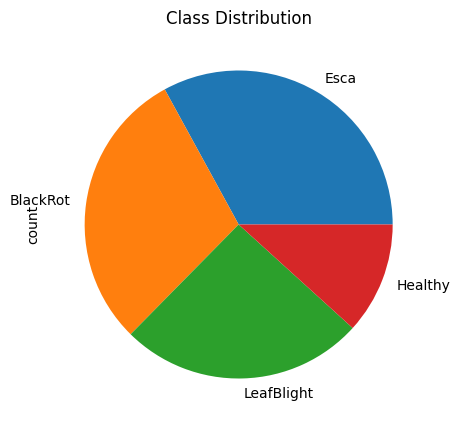

In [5]:
class_map = {'0': 'BlackRot', '1':'Esca', '2':'Healthy', '3':'LeafBlight'}
df_train['class'].replace(class_map).value_counts().plot.pie(figsize=(5, 5), title='Class Distribution')

### Samples of leaf images of every class

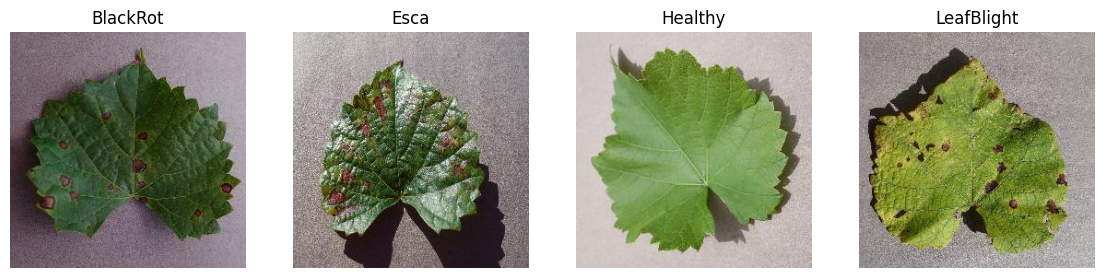

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

sample_each_class = df_train.groupby('class', group_keys=False).sample(n=1)
sample_each_class['class'] = sample_each_class['class'].replace(class_map)
f, axarr = plt.subplots(1, 4, figsize=(14,14))

for i in range(len(sample_each_class)): 
    image = Image.open(image_path + sample_each_class['file_name'].iloc[i])
    axarr[i].set_axis_off()
    axarr[i].set_title(sample_each_class["class"].iloc[i])
    axarr[i].imshow(image)

# Step 2 - Prepare MLFLow

Run `mlflow ui` in terminal

By default, it uses port 5000

On a web browser, type in `http://localhost:5000`

![homepage](asset/home_page.png)


In [7]:
import mlflow
mlflow.set_tracking_uri('http://localhost:5000')
mlflow.set_experiment("Predict leaf disease") 

<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1777544787923, experiment_id='1', last_update_time=1777544787923, lifecycle_stage='active', name='Predict leaf disease', tags={}, trace_location=None, workspace='default'>

# Step 2 - Run DINOv2

In [8]:
from IPython.display import clear_output

os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "120"
os.environ["HF_HUB_ETAG_TIMEOUT"] = "30"
from huggingface_hub import snapshot_download
model_id="facebook/dinov2-large"
snapshot_download(
    repo_id=model_id,     # model name on HF
    local_dir="dino", # your target directory
)
clear_output()

In [9]:
from transformers import AutoImageProcessor, AutoModel
import torch.nn as nn

class Model(nn.Module):
    def __init__(self, ckpt="dino"):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(ckpt)
        self.processor = AutoImageProcessor.from_pretrained(ckpt, use_fast=True)

    def forward(self, images):
        dev = next(self.parameters()).device
        inputs = self.processor(images=images, return_tensors="pt").to(dev)
        out = self.backbone(**inputs)
        feats = out.last_hidden_state[:, 0, :]
        return feats

dino = Model().to('cuda:0').eval()

/home/tasin/anaconda3/envs/ai/lib/python3.14/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


DINOv2 provides 1024 features. Let's see if ML models can classify leaf diseases.

# Step 3 - Prepare dataset

In [10]:
import torch
from torch.nn import functional as F
from pynvml import nvmlInit

nvmlInit()
mlflow.enable_system_metrics_logging()
with mlflow.start_run(run_name="DINOv2 embedding performance"):
    records = []
    with torch.no_grad():
        for i in tqdm(range(len(df_train)), desc=f'Creating training embeddings with DINO......'): 
            embedding = dino([raw_train_image[i]]) 
            image_features = F.normalize(embedding, dim=1)[-1]
            vec = image_features.detach().cpu().numpy()
            record = {
                "file_name": df_train['file_name'].iloc[i],
                "class": df_train['class'].iloc[i],
            }
            record.update({f"emb_{i}": float(v) for i, v in enumerate(vec)})
            records.append(record)
    
    emb_cols = [f"emb_{i}" for i in range(len(vec))]
    columns = ['file_name', 'class'] + emb_cols
    df_train = pd.DataFrame(records, columns=columns)
    
    records = []
    with torch.no_grad():
        for i in tqdm(range(len(df_val)), desc=f'Creating validation embeddings with DINO......'): 
            embedding = dino([raw_val_image[i]]) 
            image_features = F.normalize(embedding, dim=1)[-1]
            vec = image_features.detach().cpu().numpy()
            record = {
                "file_name": df_val['file_name'].iloc[i],
                "class": df_val['class'].iloc[i],
            }
            record.update({f"emb_{i}": float(v) for i, v in enumerate(vec)})
            records.append(record)
    
    emb_cols = [f"emb_{i}" for i in range(len(vec))]
    columns = ['file_name', 'class'] + emb_cols
    df_val = pd.DataFrame(records, columns=columns)

2026/04/30 11:27:32 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
Creating validation embeddings with DINO......: 100%|██████████| 837/837 [00:23<00:00, 34.89it/s]
2026/04/30 11:29:32 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/04/30 11:29:32 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


🏃 View run DINOv2 embedding performance at: http://localhost:5000/#/experiments/1/runs/3f7a187077644f2e8c8d042ff46f2b55
🧪 View experiment at: http://localhost:5000/#/experiments/1


Back to MLFlow Server, we can see how resources are utilised to perform the embeddings.

![system_metric](asset/system_metrics.png)

In [11]:
df_train.head()

,file_name,class,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,...,emb_1014,emb_1015,emb_1016,emb_1017,emb_1018,emb_1019,emb_1020,emb_1021,emb_1022,emb_1023
0,pv_GRBR_image (507).jpg,0,-0.073951,0.040269,0.008470,-0.013685,-0.008576,0.020800,-0.039307,-0.006323,...,0.055228,-0.029635,0.027547,0.034391,0.022460,0.050617,-0.016684,-0.000916,0.007172,-0.011440
1,pv_GRHE_image (153).jpg,2,-0.017529,0.001173,0.004125,-0.007431,-0.044669,0.018448,-0.011723,-0.031429,...,0.006482,-0.033849,0.022837,0.042358,0.021766,0.027560,0.014391,-0.052608,-0.001959,-0.005504
2,pv_GRES_image (1131).jpg,1,-0.070589,0.037511,0.014693,0.008208,-0.009320,0.022173,-0.046287,-0.014607,...,0.032415,-0.031051,0.040466,0.017691,0.021118,0.047222,-0.019759,-0.021834,0.012611,-0.008561
3,pv_GRHE_image (106).jpg,2,-0.013179,0.015685,0.002915,-0.012290,-0.040174,0.032652,-0.043231,-0.032144,...,0.027992,-0.027135,0.025819,0.025577,0.017938,0.032766,0.003925,-0.043348,-0.003417,-0.014782
4,pv_GRLB_image (201).jpg,3,-0.013274,0.028591,-0.012454,0.005556,-0.037879,0.020612,0.000416,-0.002901,...,0.039127,-0.043886,0.023222,0.027047,0.054979,0.001741,0.023398,-0.020088,0.034527,-0.006602


In [12]:
from sklearn.model_selection import  StratifiedKFold, cross_val_score

df_ml_input = df_train.drop(columns=["file_name", 'class'])
df_ml_output = df_train["class"].astype(int)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 4 - Hyperparameter tuning & Train ML
We will train KNN and XGBoost to compare classification performance.

In [13]:
import optuna
from sklearn.neighbors import KNeighborsClassifier
from IPython.display import clear_output

def objective(trial):
    params = {
            "n_neighbors": trial.suggest_int("n_neighbors", 3, 50),
            "weights":     trial.suggest_categorical("weights", ["uniform", "distance"]),
            "algorithm":   trial.suggest_categorical("algorithm", ["auto", "ball_tree", "kd_tree", "brute"]),
            "leaf_size":   trial.suggest_int("leaf_size", 10, 60),
            "p":           trial.suggest_int("p", 1, 2),  # 1 = Manhattan, 2 = Euclidean
            "metric":      trial.suggest_categorical("metric", ["minkowski", "euclidean", "manhattan"]),
            }
    
    model = KNeighborsClassifier(**params)
    with mlflow.start_run(nested=True):
        scores = cross_val_score(
            model, df_ml_input, df_ml_output,
            cv=cv,
            scoring='roc_auc_ovr',
            n_jobs=-1
        )    
        mlflow.log_params(params)
        mlflow.log_metric("roc_auc_ovr", scores.mean())
        mlflow.log_param("trial_number", trial.number)
        return scores.mean()  

with mlflow.start_run(run_name="KNN hyperparameter finetuning"):
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=30, show_progress_bar=True)
    clear_output()

2026/04/30 11:31:00 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...


🏃 View run KNN hyperparameter finetuning at: http://localhost:5000/#/experiments/1/runs/41f441519daf415cbfeac53f8a797534
🧪 View experiment at: http://localhost:5000/#/experiments/1


2026/04/30 11:31:00 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


In [14]:
knn = KNeighborsClassifier(**study.best_params)
knn.fit(df_ml_input, df_ml_output)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",31
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'manhattan'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [15]:
from xgboost import XGBClassifier

def objective(trial):
    params = {
        'n_estimators'       : trial.suggest_int('n_estimators', 200, 1000),
        'max_depth'          : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'      : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'          : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'   : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight'   : trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha'          : trial.suggest_float('reg_alpha', 1e-5, 10.0, log=True),
        'reg_lambda'         : trial.suggest_float('reg_lambda', 1e-5, 10.0, log=True),
        'gamma'              : trial.suggest_float('gamma', 0.0, 1.0),
        'eval_metric'        : 'auc',
        'enable_categorical' : True,
        'verbosity'          : 0
    }

    model = XGBClassifier(**params,device="cuda")
    with mlflow.start_run(nested=True):
        scores = cross_val_score(
            model, df_ml_input, df_ml_output,
            cv=cv,
            scoring='roc_auc_ovr',
            n_jobs=-1
        )    
        mlflow.log_params(params)
        mlflow.log_metric("roc_auc_ovr", scores.mean())
        mlflow.log_param("trial_number", trial.number)
        return scores.mean()  

with mlflow.start_run(run_name="XGBoost hyperparameter finetuning"):
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=10, show_progress_bar=True)
clear_output()

In [16]:
xg = XGBClassifier(**study.best_params, device="cuda")
xg.fit(df_ml_input, df_ml_output)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.7881084118850925
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegre

# Step 5 - Evaluation

## KNN evaluation

In [17]:
X_test = df_val.drop(columns=["file_name", 'class'])
y_test = df_val["class"].astype(int)

In [18]:
class_map = {0: 'BlackRot', 1:'Esca', 2:'Healthy', 3:'LeafBlight'}

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix,
    f1_score, accuracy_score, auc
)

# Full probability matrix: (n_samples, n_classes)
val_proba = knn.predict_proba(X_test)

# Predicted class labels
val_preds = np.argmax(val_proba, axis=1)

print("=" * 50)
print("📊 FULL MULTICLASS EVALUATION REPORT")
print("=" * 50)

# ROC-AUC (One-vs-Rest)
print(
    f"ROC-AUC Score  : "
    f"{roc_auc_score(y_test, val_proba, multi_class='ovr', average='weighted'):.5f}"
)

print(f"Accuracy       : {accuracy_score(y_test, val_preds):.5f}")
print(f"F1 Score       : {f1_score(y_test, val_preds, average='weighted'):.5f}")

print("\n📋 Classification Report:")
print(classification_report(pd.Series(y_test).replace(class_map), pd.Series(val_preds).replace(class_map)))

📊 FULL MULTICLASS EVALUATION REPORT
ROC-AUC Score  : 0.99990
Accuracy       : 0.98686
F1 Score       : 0.98682

📋 Classification Report:
              precision    recall  f1-score   support

    BlackRot       1.00      0.96      0.98       248
        Esca       0.97      1.00      0.98       276
     Healthy       0.99      0.99      0.99        98
  LeafBlight       1.00      1.00      1.00       215

    accuracy                           0.99       837
   macro avg       0.99      0.99      0.99       837
weighted avg       0.99      0.99      0.99       837



/tmp/ipykernel_17412/1858681560.py:57: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/tasin/anaconda3/envs/ai/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


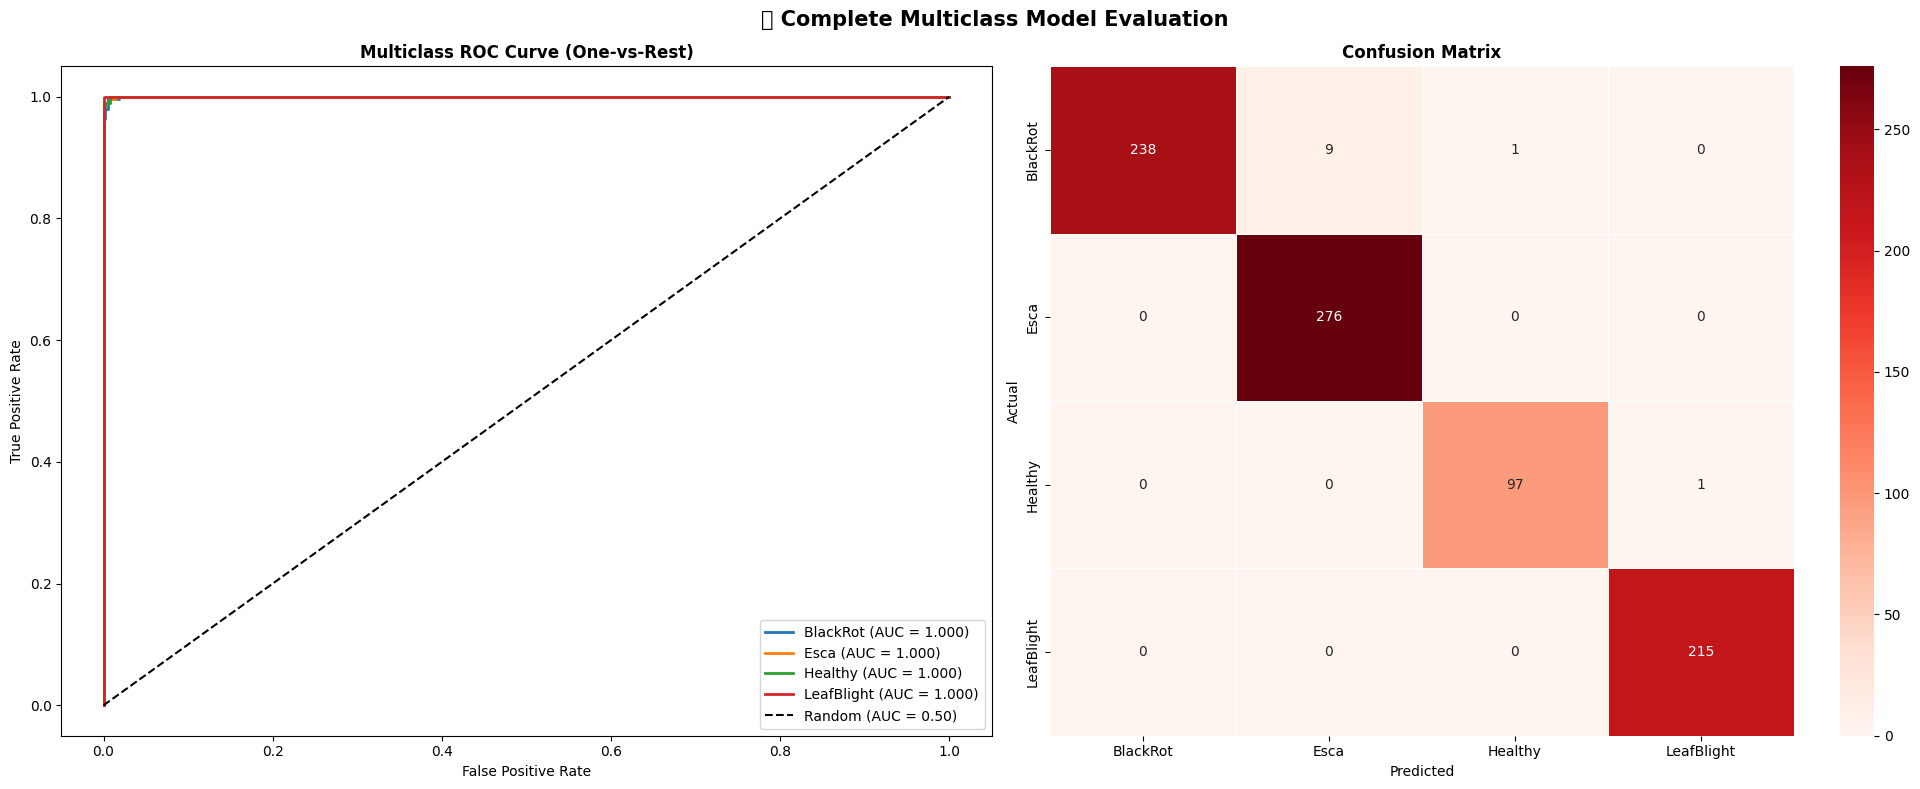

In [19]:
from sklearn.preprocessing import label_binarize
import seaborn as sns
 
class_names = knn.classes_
n_classes = len(class_names)

y_test_bin = label_binarize(y_test, classes=class_names)
class_names = pd.Series(xg.classes_).replace(class_map)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# =============================
# Plot 1: Multiclass ROC (OvR)
# =============================
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], val_proba[:, i])
    roc_auc = auc(fpr, tpr)

    axes[0].plot(
        fpr, tpr, lw=2,
        label=f"{cls} (AUC = {roc_auc:.3f})"
    )

# Random baseline
axes[0].plot([0, 1], [0, 1], "k--", lw=1.5, label="Random (AUC = 0.50)")

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Multiclass ROC Curve (One-vs-Rest)", fontweight="bold")
axes[0].legend(loc="lower right")

# =============================
# Plot 2: Confusion Matrix
# =============================
cm = confusion_matrix(y_test, val_preds)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1],
    linewidths=0.5
)

axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion Matrix", fontweight="bold")

# =============================
# Final layout
# =============================
plt.suptitle("📊 Complete Multiclass Model Evaluation",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## XGBoost evaluation

In [20]:
val_proba = xg.predict_proba(X_test)

# Predicted class labels
val_preds = np.argmax(val_proba, axis=1)

print("=" * 50)
print("📊 FULL MULTICLASS EVALUATION REPORT")
print("=" * 50)

# ROC-AUC (One-vs-Rest)
print(
    f"ROC-AUC Score  : "
    f"{roc_auc_score(y_test, val_proba, multi_class='ovr', average='weighted'):.5f}"
)

print(f"Accuracy       : {accuracy_score(y_test, val_preds):.5f}")
print(f"F1 Score       : {f1_score(y_test, val_preds, average='weighted'):.5f}")

print("\n📋 Classification Report:")
print(classification_report(pd.Series(y_test).replace(class_map), pd.Series(val_preds).replace(class_map)))

📊 FULL MULTICLASS EVALUATION REPORT
ROC-AUC Score  : 0.99999
Accuracy       : 0.99642
F1 Score       : 0.99641

📋 Classification Report:
              precision    recall  f1-score   support

    BlackRot       1.00      0.99      0.99       248
        Esca       0.99      1.00      1.00       276
     Healthy       0.99      1.00      0.99        98
  LeafBlight       1.00      1.00      1.00       215

    accuracy                           1.00       837
   macro avg       1.00      1.00      1.00       837
weighted avg       1.00      1.00      1.00       837



/home/tasin/anaconda3/envs/ai/lib/python3.14/site-packages/xgboost/core.py:774: UserWarning: [11:38:18] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


/tmp/ipykernel_17412/3628158118.py:62: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/tasin/anaconda3/envs/ai/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


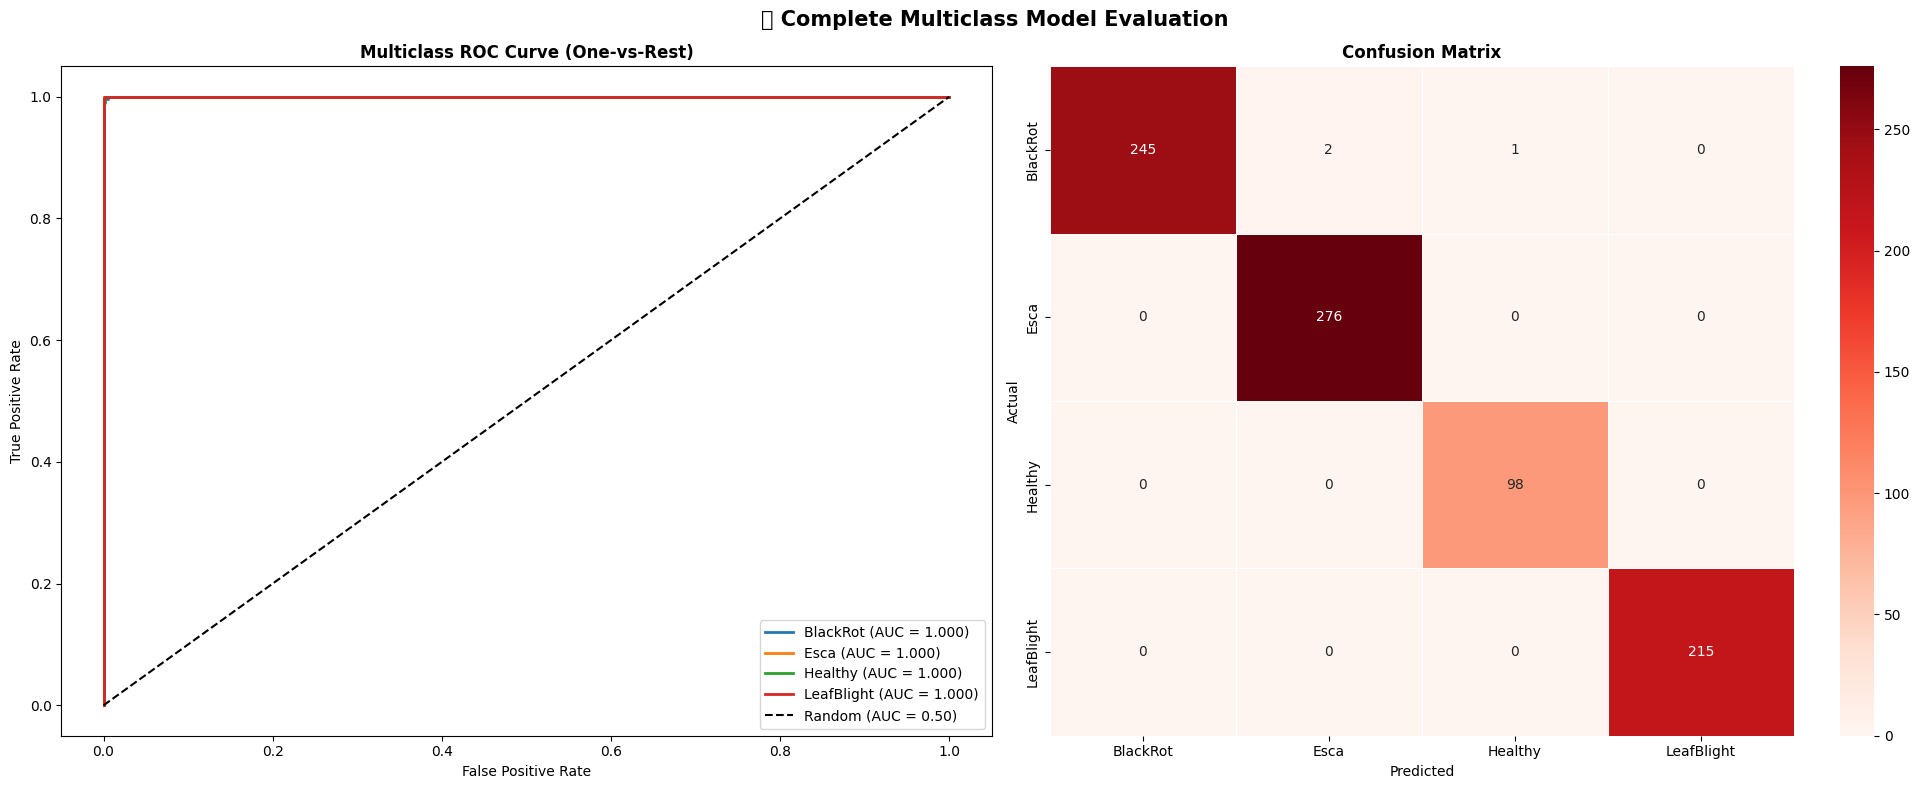

In [21]:
from sklearn.preprocessing import label_binarize

# -----------------------------
# Setup
# -----------------------------
class_names = xg.classes_
n_classes = len(class_names)

val_proba = xg.predict_proba(X_test)
val_preds = np.argmax(val_proba, axis=1)

y_test_bin = label_binarize(y_test, classes=class_names)
class_names = pd.Series(xg.classes_).replace(class_map)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# =============================
# Plot 1: Multiclass ROC (OvR)
# =============================
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], val_proba[:, i])
    roc_auc = auc(fpr, tpr)

    axes[0].plot(
        fpr, tpr, lw=2,
        label=f"{cls} (AUC = {roc_auc:.3f})"
    )

# Random baseline
axes[0].plot([0, 1], [0, 1], "k--", lw=1.5, label="Random (AUC = 0.50)")

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Multiclass ROC Curve (One-vs-Rest)", fontweight="bold")
axes[0].legend(loc="lower right")

# =============================
# Plot 2: Confusion Matrix
# =============================
cm = confusion_matrix(y_test, val_preds)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1],
    linewidths=0.5
)

axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion Matrix", fontweight="bold")

# =============================
# Final layout
# =============================
plt.suptitle("📊 Complete Multiclass Model Evaluation",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# Step 6 - Deploy model

In [22]:
from io import BytesIO
import base64, json

class DinoWrapper(mlflow.pyfunc.PythonModel):
    def load_context(self, context):
        self.dino = dino 
        self.xg = xg 
    
    def predict(self, context, model_input):
        data = model_input.to_dict(orient="records")[0]
        img_b64 = data["image"][0]
        im = Image.open(BytesIO(base64.b64decode(img_b64)))
        embedding = self.dino([im]) 
        image_features = F.normalize(embedding, dim=1)[-1]
        vec = image_features.detach().cpu().numpy().reshape(1, -1)
        emb_cols = [f"emb_{i}" for i in range(vec.shape[1])]
        embedding_df = pd.DataFrame(vec, columns=emb_cols)
        val_preds = self.xg.predict(embedding_df)
        return val_preds
       
mlflow.pyfunc.log_model(
    name="leaf_disease_detector",
    python_model=DinoWrapper(),
)

/home/tasin/anaconda3/envs/ai/lib/python3.14/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
2026/04/30 11:39:25 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/04/30 11:39:35 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.25.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.25.0' without the local version label to make 

DINOv2 should appear in MLFLow

![log models](asset/logging_model.png)

Register the model

![register](asset/register_model.png)

# Step 7 - Serve model

Go to terminal and type the following:

`export MLFLOW_TRACKING_URI=http://localhost:5000`

Install pyenv:

https://github.com/pyenv/pyenv#installation

`mlflow models serve -m models:/predict_leaf_disease/1 -p 5001` DINO

Restart the kernel and use the `step 2` notebook to use the REST API